In [1]:
# Intalando bibliotecas
!pip install pandas matplotlib seaborn openpyxl

In [4]:
# Carregando os dados da PNS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_pns = pd.read_csv("../data/raw/pns2019_microdados.csv")
df_pns.head()

,V0001,V0024,UPA_PNS,V0006_PNS,V0015,V0020,V0022,V0026,V0031,V0025A,...,VDE002,VDE014,VDF002,VDF003,VDF004,VDL001,VDM001,VDP001,VDR001,VDDATA
0,11,1110011,110000016,1,1,2019,6.0,1,1,1.0,...,1.0,6.0,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20210825
1,11,1110011,110000016,1,1,2019,6.0,1,1,0.0,...,NaN,NaN,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20210825
2,11,1110011,110000016,1,1,2019,6.0,1,1,0.0,...,1.0,4.0,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20210825
3,11,1110011,110000016,1,1,2019,6.0,1,1,9.0,...,NaN,NaN,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20210825
4,11,1110011,110000016,1,1,2019,6.0,1,1,9.0,...,NaN,NaN,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20210825


In [ ]:
#Limpando e organizando os dados da PNS
# De acordo com a última atualização da correção e atualização dos rótulos de módulos no dicionário da PNS 2019, os seguintes rótulos equivalem as váriaveis de interesse dessa análise: 
# C006 - Sexo  (1 homem; 2 mulher)
# C008 - Idade
# sigla_uf - Região
# Q092 - Diagnóstico de depressão (1 = sim; 2= não)

# PASSO 1 — Criar variável binária excluindo os NaN do Q092
# Apenas quem respondeu (1.0 ou 2.0) entra no cálculo
df_pns_depressao = df_pns[df_pns["Q092"].notna()].copy()

df_pns_depressao["depressao_bin"] = (df_pns_depressao["Q092"] == 1.0).astype(int)

# PASSO 2 — Faixas etárias a partir de C008
df_pns_depressao["faixa_etaria"] = pd.cut(
    df_pns_depressao["C008"],
    bins=[17, 29, 39, 49, 59, 69, 120],
    labels=["18–29", "30–39", "40–49", "50–59", "60–69", "70+"]
)

# PASSO 3 — Rótulo legível para sexo
df_pns_depressao["sexo_label"] = df_pns_depressao["C006"].map({1: "Homem", 2: "Mulher"})

# Verificação rápida
print(f"Total com resposta válida: {len(df_pns_depressao)}")
print(f"Com diagnóstico de depressão: {df_pns_depressao['depressao_bin'].sum()}")
print(f"Prevalência geral: {df_pns_depressao['depressao_bin'].mean() * 100:.1f}%")

Total com resposta válida: 90846
Com diagnóstico de depressão: 8332
Prevalência geral: 9.2%


C:\Users\desid\AppData\Local\Temp\ipykernel_1524\1939798964.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


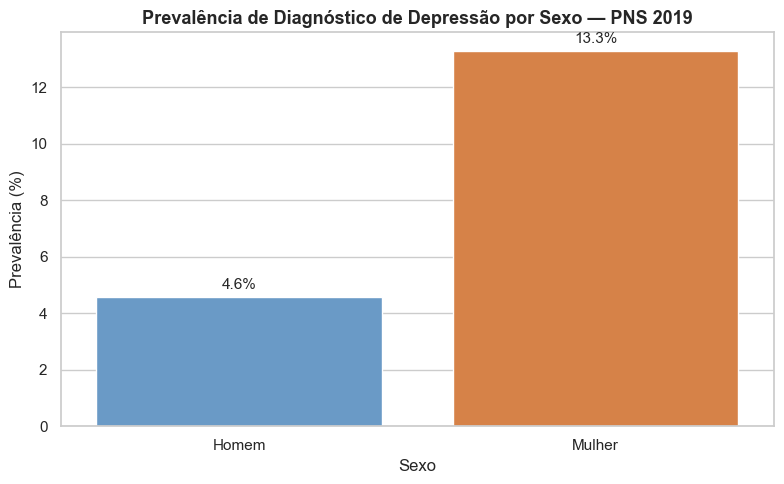

In [ ]:
#Gráfico 1 Prevalência por sexo
fig, ax = plt.subplots(figsize=(8, 5))

contagem = (df_pns_depressao.groupby("sexo_label")["depressao_bin"].mean() * 100)

sns.barplot(
    x=contagem.index,
    y=contagem.values,
    ax=ax,
    palette=["#5B9BD5", "#ED7D31"]
)

# Adicionar os valores em cima de cada barra
for i, valor in enumerate(contagem.values):
    ax.text(i, valor + 0.3, f"{valor:.1f}%", ha="center", fontsize=11)

ax.set_title("Prevalência de Diagnóstico de Depressão por Sexo — PNS 2019",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Sexo")
ax.set_ylabel("Prevalência (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/03_depressao_por_sexo.png", dpi=150)
plt.show()

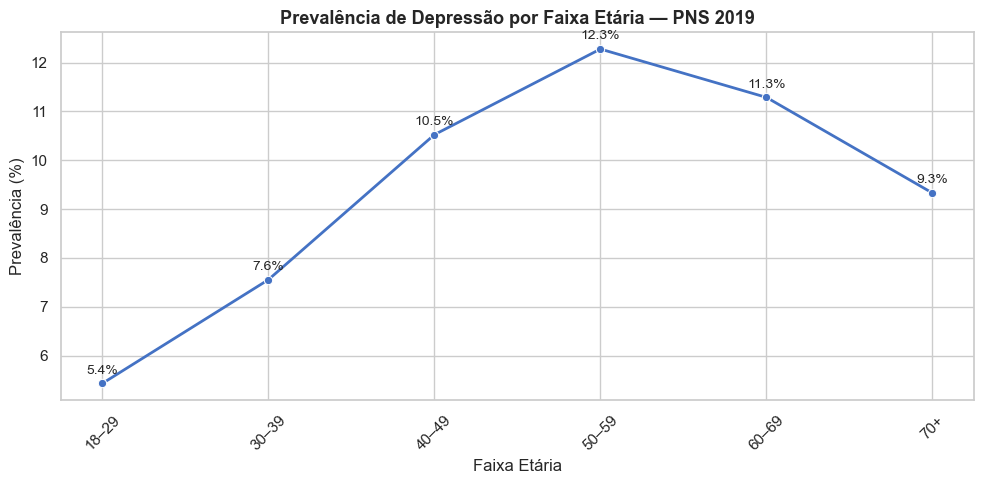

In [15]:
#Gráfico 2 prevalência por faixa etária
fig, ax = plt.subplots(figsize=(10, 5))

prev_idade = (
    df_pns_depressao.groupby("faixa_etaria", observed=True)["depressao_bin"]
    .mean() * 100
)

sns.lineplot(
    x=prev_idade.index.astype(str),
    y=prev_idade.values,
    marker="o",
    color="#4472C4",
    linewidth=2,
    ax=ax
)

# Adicionar os valores em cada ponto
for i, (faixa, valor) in enumerate(zip(prev_idade.index, prev_idade.values)):
    ax.text(i, valor + 0.2, f"{valor:.1f}%", ha="center", fontsize=10)

ax.set_title("Prevalência de Depressão por Faixa Etária — PNS 2019",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Faixa Etária")
ax.set_ylabel("Prevalência (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../outputs/figures/04_depressao_por_faixa_etaria.png", dpi=150)
plt.show()

In [17]:

# Exportar dados da PNS (depressão)
df_pns_depressao.to_csv(
    "../data/processed/para_powerbi_pns.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos exportados com sucesso!")

Arquivos exportados com sucesso!
